# SMS SPAM DEEP LEARNING
Etudiant : Amaury TISSOT

Classe : [DIS] MIA 26.2

## Dépendances

In [35]:
# Installation des dépendances du projet listées dans requirements.txt
# !pip install -r ../requirements.txt

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Choix du dataset
Etant un véritable novice en matière de deeplearning, j'ai choisi le dataset suivant : [SMS Spam Collection — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) qui me semble approprié pour découvrir le concept de RNN.

## Importation du dataset

In [37]:
import io
import os
import zipfile
import urllib.request

DATA_DIR = "../data"
CSV_PATH = os.path.join(DATA_DIR, "sms_spam.csv")
URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Téléchargement + extraction au premier lancement, puis lecture du cache local ensuite
if not os.path.exists(CSV_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    raw = urllib.request.urlopen(URL, timeout=60).read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        with z.open("SMSSpamCollection") as f:
            df = pd.read_csv(f, sep="\t", header=None, names=["label", "message"])
    df.to_csv(CSV_PATH, index=False)
else:
    df = pd.read_csv(CSV_PATH)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploration des données (EDA)

### 1. Aperçu général

In [38]:
print("Dimensions (lignes, colonnes) :", df.shape)
df.info()

Dimensions (lignes, colonnes) : (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### 2. Valeurs manquantes et doublons

In [39]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print("\nNombre de lignes en double :", df.duplicated().sum())

Valeurs manquantes par colonne :
label      0
message    0
dtype: int64

Nombre de lignes en double : 403


On supprime les doublons pour ne garder qu'un exemplaire de chaque message. `reset_index(drop=True)` renumérote les lignes proprement après suppression.

In [40]:
df = df.drop_duplicates().reset_index(drop=True)
print("Nouvelles dimensions du dataframe après suppression des doublons :", df.shape)

Nouvelles dimensions du dataframe après suppression des doublons : (5169, 2)


### 3. Répartition des classes (équilibre)

On regarde combien de "ham" ( messages légitimes) et de "spam" le data set contient.

- `value_counts()` compte les occurrences.
- `value_counts(normalize=True)` donne les proportions (en %).

In [41]:
print("Effectifs :")
print(df["label"].value_counts())
print("\nProportions :")
print((df["label"].value_counts(normalize=True) * 100).round(1))

Effectifs :
label
ham     4516
spam     653
Name: count, dtype: int64

Proportions :
label
ham     87.4
spam    12.6
Name: proportion, dtype: float64


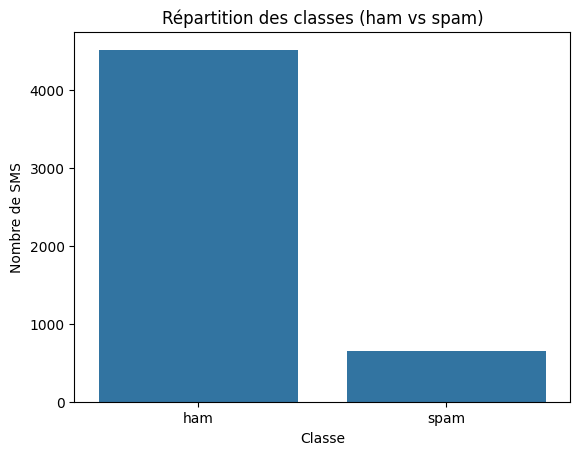

In [42]:
sns.countplot(data=df, x="label")
plt.title("Répartition des classes (ham vs spam)")
plt.xlabel("Classe")
plt.ylabel("Nombre de SMS")
plt.show()

On voit que les "ham" sont majoritaires (~87 %) face aux "spam" (~13 %) : le dataset est donc déséquilibré.

### 4. Longueur des messages

On vient comparer la longueur des messages "hame" et "spam".

In [43]:
df["length"] = df["message"].str.len()
df.groupby("label")["length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


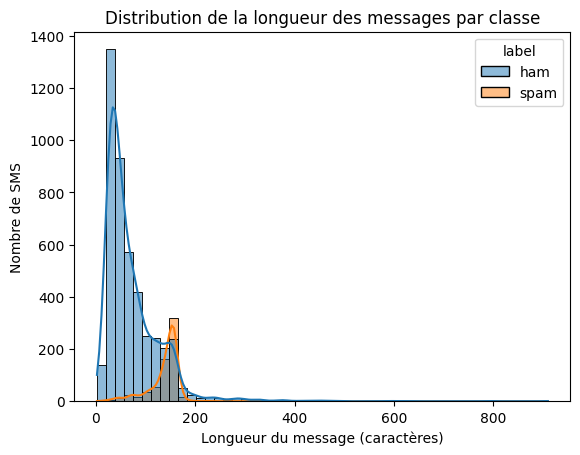

In [44]:
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribution de la longueur des messages par classe")
plt.xlabel("Longueur du message (caractères)")
plt.ylabel("Nombre de SMS")
plt.show()

On constate que les ham sont plus courts en moyenne que les spam.
La longueur des messages semble donc être un possible signal discriminant.

### 5. Extrait des données



In [45]:
print("Exemples de messages légitimes (HAM) :")
for msg in df[df["label"] == "ham"]["message"].head(3):
    print("-", msg)

print("\nExemples de messages de SPAM ===")
for msg in df[df["label"] == "spam"]["message"].head(3):
    print("-", msg)

Exemples de messages légitimes (HAM) :
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
- Ok lar... Joking wif u oni...
- U dun say so early hor... U c already then say...

Exemples de messages de SPAM ===
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv
- WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.
